# Sunchart Plage Inference

Run full-chart plage inference and save derived masks and measurements.

**Configuration:** Set model, disk-catalogue, input, and output paths before execution.

In [1]:
# Step 1: Import dependencies and initialise this stage.
import os
import cv2
from PIL import Image
import glob
import numpy as np
from matplotlib import pyplot as plt
from patchify import patchify, unpatchify

In [2]:
# Step 2: Import dependencies and initialise this stage.
from tensorflow.keras.models import load_model
model = load_model("/home/dibya/ML_work/sunchart_plage_segmentation_model.h5",compile=False)

2025-07-03 00:28:28.469805: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-03 00:28:28.481232: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-03 00:28:28.507583: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-03 00:28:28.547709: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-03 00:28:28.559800: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-03 00:28:30.140919: W tensorflow/compiler/tf2tensorrt/utils/p

In [3]:
# Step 3: Import dependencies and initialise this stage.
import scipy
import scipy.io as sio 
from scipy.io import readsav

In [4]:
# Step 4: Import dependencies and initialise this stage.
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils

In [ ]:
# Step 5: Run the next processing stage.
directory = "/kodaiData/Drawings/Raw/2007/HR/"

name_image =[]
for root, _, files in os.walk(directory):
        for filename in files:
            if filename.endswith('.tif'):
                name_image.append(filename)
                name_image.sort()
print(name_image)

['sch_20070101_0740_kxxx.tif', 'sch_20070102_1010_kxxx.tif', 'sch_20070103_0925_kxxx.tif', 'sch_20070104_1407_kxxx.tif', 'sch_20070105_0749_kxxx.tif', 'sch_20070106_0744_kxxx.tif', 'sch_20070107_0725_kxxx.tif', 'sch_20070108_0722_kxxx.tif', 'sch_20070110_0729_kxxx.tif', 'sch_20070111_0810_kxxx.tif', 'sch_20070113_0755_kxxx.tif', 'sch_20070114_0747_kxxx.tif', 'sch_20070115_0955_kxxx.tif', 'sch_20070116_0815_kxxx.tif', 'sch_20070117_0920_kxxx.tif', 'sch_20070118_0840_kxxx.tif', 'sch_20070119_1107_kxxx.tif', 'sch_20070120_0747_kxxx.tif', 'sch_20070121_0840_kxxx.tif', 'sch_20070122_0944_kxxx.tif', 'sch_20070123_0745_kxxx.tif', 'sch_20070124_0730_kxxx.tif', 'sch_20070125_0758_kxxx.tif', 'sch_20070126_0745_kxxx.tif', 'sch_20070130_0805_kxxx.tif', 'sch_20070131_0735_kxxx.tif', 'sch_20070201_0745_kxxx.tif', 'sch_20070202_0742_kxxx.tif', 'sch_20070203_0730_kxxx.tif', 'sch_20070204_0735_kxxx.tif', 'sch_20070205_0730_kxxx.tif', 'sch_20070206_0742_kxxx.tif', 'sch_20070207_0732_kxkx.tif', 'sch_2007

In [6]:
# Step 6: Run the next processing stage.
len(name_image)

209

In [7]:
# Step 7: Import dependencies and initialise this stage.
import pandas as pd
import math
from array import array
import numpy as np


In [ ]:
# Step 8: Run the next processing stage.


file_path = "/home/dibya/ML_work/solar_disk_geometry_catalog.txt"  # Replace with the actual path to your text file

x =[]
y=[]
ra=[]
angle =[]

with open(file_path, "r") as file:
    lines = file.readlines()[31237: 31446] #2725,3059
    
    # Create a list to store the data
    data = []
        
    # Iterate through the lines and split them by whitespace
    for line in lines:
        line_data = line.strip().split()
        data.append(line_data)
        
    # Create a pandas DataFrame
    df = pd.DataFrame(data,columns=['file_name','xcen','ycen','rad','ang'])
    
    xcen = df['xcen'].astype('float')
    ycen = df['ycen'].astype('float')
    rad = df['rad'].astype('float')
    ang = df['ang'].astype('float')
    
    
    

    # Match the file name with the 'file_name' column
    matching_rows = df['file_name'] == name_image
    # Check if there are any matching rows
    if not matching_rows.empty:
      print("File name matched!")
    # Process the matching rows here
    else:
      print("File name not found.")
    x.append(round(xcen[0:]))
    y.append(round(ycen[0:]))
    ra.append(round(rad[0:]))
    angle.append(round(ang[0:],2))
   
    
    shape = np.shape(df)
    #print(x)

x = np.reshape(x,(shape[0],1))
y = np.reshape(y,(shape[0],1))
ra = np.reshape(ra,(shape[0],1))
angle = np.reshape(angle,(shape[0],1))


x = [int(element) for element in x]
y = [int(element) for element in y]
ra = [int(element) for element in ra]
angle = [float(element) for element in angle]



print(x)
print(y)
print(ra)
print(angle)

File name matched!
[2544, 2568, 2616, 2568, 2616, 3048, 3048, 2976, 2808, 2784, 3240, 3240, 2520, 3240, 2496, 2520, 2496, 2496, 2568, 2592, 2520, 2448, 2424, 2424, 2472, 2520, 2496, 2496, 2544, 2496, 2424, 2952, 2952, 2928, 2904, 2448, 2472, 2424, 2424, 2376, 2496, 2472, 2472, 2544, 2544, 2520, 2400, 2592, 2496, 2472, 2424, 2448, 2400, 2640, 2496, 2376, 2448, 2712, 3120, 3192, 3192, 3144, 3144, 3120, 3120, 3072, 2568, 2448, 2448, 2448, 2448, 2472, 2448, 2424, 2424, 2472, 2448, 2472, 2544, 2472, 2904, 2952, 2928, 2424, 2496, 2400, 2496, 2472, 2520, 2520, 2472, 2472, 2472, 2472, 2472, 2448, 2544, 2520, 2520, 2496, 3048, 3024, 3024, 2760, 2712, 2712, 2688, 2952, 2544, 2544, 2592, 2496, 2496, 2496, 2544, 2976, 3000, 2952, 3048, 3024, 3048, 3048, 3120, 3000, 2952, 2856, 2952, 2928, 2928, 3024, 2928, 2928, 2928, 3072, 3216, 3072, 3048, 3048, 3048, 2976, 3048, 2448, 2472, 2832, 3216, 2448, 3120, 3120, 3144, 3096, 3096, 3072, 3120, 3048, 3048, 3048, 3144, 3144, 3144, 3120, 3048, 3072, 3024, 30

/tmp/ipykernel_20744/3503954289.py:54: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x = [int(element) for element in x]
/tmp/ipykernel_20744/3503954289.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = [int(element) for element in y]
/tmp/ipykernel_20744/3503954289.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ra = [int(element) for element in ra]
/tmp/ipykernel_20744/3503954289.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a sca

In [9]:
# Step 9: Import dependencies and initialise this stage.
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv2
import glob
import os, sys
import imutils

In [ ]:
# Step 10: Import dependencies and initialise this stage.
import random
image_dataset = []

x0_main = []
y0_main = []
rad_main = []


image_directory = "/kodaiData/Drawings/Raw/2007/HR/"
"

tif_files = [os.path.join(root, filename) for root, _, files in os.walk(image_directory) for filename in files if filename.endswith('.tif')]
tif_files.sort()

for k,image_path in enumerate(tif_files):
                filename = os.path.splitext(os.path.basename(image_path))[0]
                print(filename)
                
                image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)
                image = cv2.flip(image,0)
                image = imutils.rotate(image,angle=angle[k])
                # do not crop this
                image = image[y[k]-ra[k]:y[k]+ra[k],x[k]-ra[k]:x[k]+ra[k]]
                image = Image.fromarray(image)
                image = image.resize((2048,2048))
                
                
                
                x0_main.append(np.round((x[k]/6144.0)*2048.0))
                y0_main.append(np.round((y[k]/6144.0)*2048.0))
                rad_main.append(np.round((ra[k]/6144.0)*2048.0))
                
                
                patches_img = patchify(np.array(image), (512,512,3), step=512)#512
                
                
                for i in range(patches_img.shape[0]):
                    for j in range(patches_img.shape[1]):
                        single_patch_img = patches_img[i, j,0,:,:,:]
                        b,g,r=cv2.split(single_patch_img)
                        img_matplotlib=cv2.merge([r,g,b])
                       
                        
                        
                        image_dataset.append(np.array(img_matplotlib))
                        
                       
print(x0_main)                       

sch_20070101_0740_kxxx
sch_20070102_1010_kxxx
sch_20070103_0925_kxxx
sch_20070104_1407_kxxx
sch_20070105_0749_kxxx
sch_20070106_0744_kxxx
sch_20070107_0725_kxxx
sch_20070108_0722_kxxx
sch_20070110_0729_kxxx
sch_20070111_0810_kxxx
sch_20070113_0755_kxxx
sch_20070114_0747_kxxx
sch_20070115_0955_kxxx
sch_20070116_0815_kxxx
sch_20070117_0920_kxxx
sch_20070118_0840_kxxx
sch_20070119_1107_kxxx
sch_20070120_0747_kxxx
sch_20070121_0840_kxxx
sch_20070122_0944_kxxx
sch_20070123_0745_kxxx
sch_20070124_0730_kxxx
sch_20070125_0758_kxxx
sch_20070126_0745_kxxx
sch_20070130_0805_kxxx
sch_20070131_0735_kxxx
sch_20070201_0745_kxxx
sch_20070202_0742_kxxx
sch_20070203_0730_kxxx
sch_20070204_0735_kxxx
sch_20070205_0730_kxxx
sch_20070206_0742_kxxx
sch_20070207_0732_kxkx
sch_20070208_0000_kxxx
sch_20070209_0932_kxxx
sch_20070212_0830_kxxx
sch_20070213_0742_kxxx
sch_20070214_0738_kxkx
sch_20070215_0743_kxxx
sch_20070216_0758_kxxx
sch_20070217_0815_kxxx
sch_20070220_0909_kxxx
sch_20070221_0732_kxxx
sch_2007022

In [11]:
# Step 11: Run the next processing stage.
images = np.array(image_dataset)

In [12]:
# Step 12: Run the next processing stage.
images.shape

(3344, 512, 512, 3)

In [13]:
# Step 13: Run the next processing stage.
print("Images shape:", images.shape)
print("First patch sample values:", images[0, 0, 0, :])


Images shape: (3344, 512, 512, 3)
First patch sample values: [199 198 171]


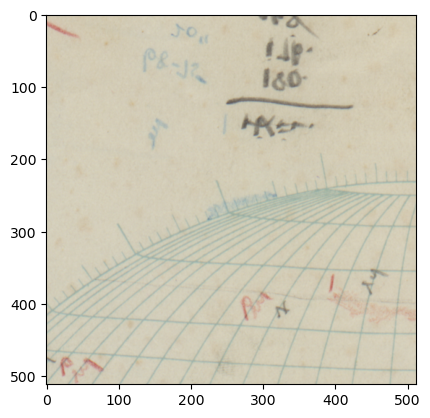

In [9]:
# Step 14: Visualise intermediate or final results.
plt.imshow(images[1])

In [ ]:
# Step 15: Import dependencies and initialise this stage.
import numpy as np



# Reshape into (2 images, 4x4 grid of patches, 512x512x3 per patch)
reshape_rgb = np.reshape(images, (343, 4, 4, 512, 512, 3))#334

# Initialize list to store reconstructed full images
full_image_rgb = []

# Loop through each image
for i in range(reshape_rgb.shape[0]):  # Iterate over the number of images
    # Initialize a blank canvas for the current image
    reconstructed_image = np.zeros((2048, 2048, 3), dtype=reshape_rgb.dtype)
    
    # Map patches to their corresponding positions
    for x in range(4):  # Row index in the patch grid
        for y in range(4):  # Column index in the patch grid
            # Calculate the start and end positions for the patch in the reconstructed image
            x_start, x_end = x * 512, (x + 1) * 512
            y_start, y_end = y * 512, (y + 1) * 512
            
            # Place the patch into the reconstructed image
            reconstructed_image[x_start:x_end, y_start:y_end] = reshape_rgb[i, x, y]
    
    # Append the reconstructed image to the list
    full_image_rgb.append(reconstructed_image)

# Check the reconstructed images
for idx, img in enumerate(full_image_rgb):
    print(f"Reconstructed Image {idx + 1} Shape: {img.shape}")

Reconstructed Image 1 Shape: (2048, 2048, 3)
Reconstructed Image 2 Shape: (2048, 2048, 3)
Reconstructed Image 3 Shape: (2048, 2048, 3)
Reconstructed Image 4 Shape: (2048, 2048, 3)
Reconstructed Image 5 Shape: (2048, 2048, 3)
Reconstructed Image 6 Shape: (2048, 2048, 3)
Reconstructed Image 7 Shape: (2048, 2048, 3)
Reconstructed Image 8 Shape: (2048, 2048, 3)
Reconstructed Image 9 Shape: (2048, 2048, 3)
Reconstructed Image 10 Shape: (2048, 2048, 3)
Reconstructed Image 11 Shape: (2048, 2048, 3)
Reconstructed Image 12 Shape: (2048, 2048, 3)
Reconstructed Image 13 Shape: (2048, 2048, 3)
Reconstructed Image 14 Shape: (2048, 2048, 3)
Reconstructed Image 15 Shape: (2048, 2048, 3)
Reconstructed Image 16 Shape: (2048, 2048, 3)
Reconstructed Image 17 Shape: (2048, 2048, 3)
Reconstructed Image 18 Shape: (2048, 2048, 3)
Reconstructed Image 19 Shape: (2048, 2048, 3)
Reconstructed Image 20 Shape: (2048, 2048, 3)
Reconstructed Image 21 Shape: (2048, 2048, 3)
Reconstructed Image 22 Shape: (2048, 2048, 

In [24]:
# Step 16: Run the next processing stage.
len(full_image_rgb)

363

In [ ]:
# Step 17: Run the next processing stage.
reconstruct_rgb = np.array(full_image_rgb)

In [14]:
# Step 18: Run the next processing stage.
reconstruct_rgb.shape

(3, 2048, 2048, 3)

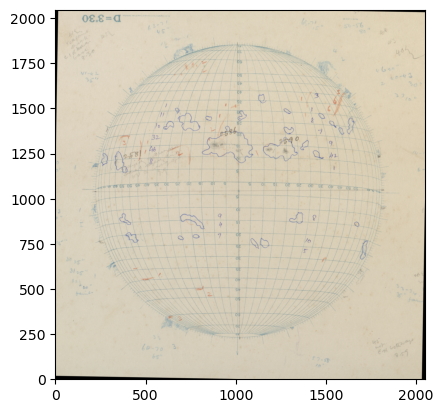

In [15]:
# Step 20: Visualise intermediate or final results.
plt.imshow(reconstruct_rgb[2],origin='lower')#,cmap='gray')

In [14]:
# Step 21: Import dependencies and initialise this stage.
import os
import cv2
import numpy as np
from PIL import Image

In [ ]:
# Step 23: Import dependencies and initialise this stage.
import random
predicted_masks =[]
import matplotlib.pyplot as plt

for i in range(0,3344): #5344
    b,g,r=cv2.split(images[i])
    img_matplotlib_xtest=cv2.merge([r,g,b])
    prediction = model.predict(images[i].reshape(1,512,512,3))    
    prediction = prediction.reshape(512,512)
    
    y_train_ = np.reshape(prediction,(512,512))
    mask = (y_train_ >= 0.1).astype(int) #0.3
    mask = mask.clip(max=1)
    predicted_masks.append(mask)
    


plt.show()

1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 3s 3s/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 335ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 337ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 336ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 335ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 345ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 328ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 337ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 341ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 338ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 343ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 347ms/step
1/1 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”

In [16]:
# Step 24: Generate or inspect model predictions.
len(predicted_masks) 

3344

In [17]:
# Step 25: Generate or inspect model predictions.
masks = np.array(predicted_masks)

In [18]:
# Step 26: Run the next processing stage.
masks.shape

(3040, 512, 512)

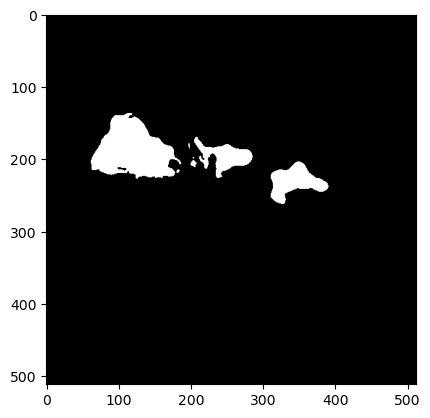

In [18]:
# Step 27: Visualise intermediate or final results.
plt.imshow(masks[25],cmap='gray')

In [ ]:
# Step 28: Import dependencies and initialise this stage.
import numpy as np



# Reshape into (2 images, 4x4 grid of patches, 512x512x3 per patch)
reshape = np.reshape(masks, (209, 4, 4, 512, 512))#221

# Initialize list to store reconstructed full images
full_image = []

# Loop through each image
for i in range(reshape.shape[0]):  # Iterate over the number of images
    # Initialize a blank canvas for the current image
    reconstructed_image = np.zeros((2048, 2048), dtype=reshape.dtype)
    
    # Map patches to their corresponding positions
    for x in range(4):  # Row index in the patch grid
        for y in range(4):  # Column index in the patch grid
            # Calculate the start and end positions for the patch in the reconstructed image
            x_start, x_end = x * 512, (x + 1) * 512
            y_start, y_end = y * 512, (y + 1) * 512
            
            # Place the patch into the reconstructed image
            reconstructed_image[x_start:x_end, y_start:y_end] = reshape[i, x, y]
    
    # Append the reconstructed image to the list
    full_image.append(reconstructed_image)
    
# Check the reconstructed images
for idx, img in enumerate(full_image):
    print(f"Reconstructed Image {idx + 1} Shape: {img.shape}")

Reconstructed Image 1 Shape: (2048, 2048)
Reconstructed Image 2 Shape: (2048, 2048)
Reconstructed Image 3 Shape: (2048, 2048)
Reconstructed Image 4 Shape: (2048, 2048)
Reconstructed Image 5 Shape: (2048, 2048)
Reconstructed Image 6 Shape: (2048, 2048)
Reconstructed Image 7 Shape: (2048, 2048)
Reconstructed Image 8 Shape: (2048, 2048)
Reconstructed Image 9 Shape: (2048, 2048)
Reconstructed Image 10 Shape: (2048, 2048)
Reconstructed Image 11 Shape: (2048, 2048)
Reconstructed Image 12 Shape: (2048, 2048)
Reconstructed Image 13 Shape: (2048, 2048)
Reconstructed Image 14 Shape: (2048, 2048)
Reconstructed Image 15 Shape: (2048, 2048)
Reconstructed Image 16 Shape: (2048, 2048)
Reconstructed Image 17 Shape: (2048, 2048)
Reconstructed Image 18 Shape: (2048, 2048)
Reconstructed Image 19 Shape: (2048, 2048)
Reconstructed Image 20 Shape: (2048, 2048)
Reconstructed Image 21 Shape: (2048, 2048)
Reconstructed Image 22 Shape: (2048, 2048)
Reconstructed Image 23 Shape: (2048, 2048)
Reconstructed Image 

In [ ]:
# Step 29: Run the next processing stage.
print(reconstructed_image)

In [34]:
# Step 30: Import dependencies and initialise this stage.
import cv2
import numpy as np
import glob
import os
from collections import defaultdict

# Parameters
patch_size = 512
original_size = 2048
num_patches_per_side = original_size // patch_size  # 4
patches_per_image = num_patches_per_side ** 2  # 16
target_values = {125, 194}  # Values to set to 1

# Load all patch files (sorted)
patch_files = sorted(glob.glob("/home/dibya/ML_work/test_pole_mask/*.png"))

# Group patches by (date + time)
date_time_to_patches = defaultdict(list)
for patch_path in patch_files:
    filename = os.path.basename(patch_path)
    parts = filename.split('_')
    row, col = int(parts[0]), int(parts[1])
    date, time = parts[3], parts[4]  # e.g., "19590101", "0804"
    date_time = f"{date}_{time}"  # Unique identifier per image
    date_time_to_patches[date_time].append((row, col, patch_path))

# Initialize full output array (366 days, 2048x2048)
full_images = np.zeros((366, original_size, original_size), dtype=np.uint8)

# Reconstruct each image
for idx, (date_time, patches) in enumerate(date_time_to_patches.items()):
    if len(patches) != patches_per_image:
        print(f"âš ï¸ Skipping {date_time}: Expected {patches_per_image} patches, found {len(patches)}")
        continue

    # Place patches in grid
    img_grid = np.zeros((original_size, original_size), dtype=np.uint8)
    for (row, col, patch_path) in patches:
        patch = cv2.imread(patch_path, cv2.IMREAD_GRAYSCALE)
        binary_patch = np.isin(patch, list(target_values)).astype(np.uint8)  # 0 or 1
        img_grid[
            row * patch_size : (row + 1) * patch_size,
            col * patch_size : (col + 1) * patch_size
        ] = binary_patch

    # Assign to output array (366, 2048, 2048)
    full_images[idx] = img_grid

# Save as .npy (or split into individual PNGs)

print(f"âœ… Saved {len(date_time_to_patches)} images (shape: {full_images.shape})")

âœ… Saved 366 images (shape: (366, 2048, 2048))


In [ ]:
# Step 31: Import dependencies and initialise this stage.

import numpy as np

def mask_outside_circle(array, center, radius):
    """
    Remove (mask) values outside a given radius from a circle in a 2D array.

    Parameters:
    array (numpy.ndarray): The input 2D array.
    center (tuple): The (x, y) coordinates of the circle center.
    radius (float): The radius of the circle.

    Returns:
    numpy.ndarray: A 2D array with values outside the circle set to 0 (or masked).
    """
    x_center, y_center = center
    
    # Create a grid of indices matching the array's shape
    y_indices, x_indices = np.ogrid[:array.shape[0], :array.shape[1]]

    # Calculate the distance from the center for each point
    distance_from_center = np.sqrt((x_indices - x_center)**2 + (y_indices - y_center)**2)

    # Mask values outside the radius
    mask = distance_from_center <= radius

    # Apply the mask: keep values inside the circle, set others to 0
    masked_array = np.where(mask, array, 0)

    return masked_array



In [20]:
# Step 32: Run the next processing stage.
reconstruct = np.array(full_image)

In [35]:
# Step 33: Run the next processing stage.
reconstruct = np.array(full_images)

In [37]:
# Step 34: Run the next processing stage.
reconstruct.shape

(363, 2048, 2048)

In [33]:
# Step 35: Run the next processing stage.
print("Pixel values in the mask are: ", np.unique(reconstruct))

Pixel values in the mask are:  [0 1]


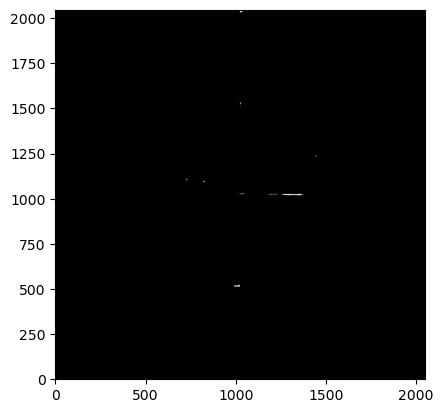

In [21]:
# Step 36: Visualise intermediate or final results.
plt.imshow(reconstruct[10],cmap='gray',origin='lower')

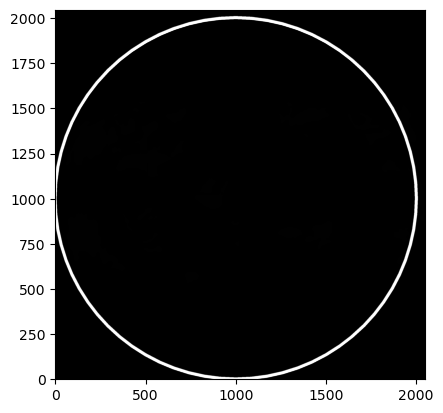

In [41]:
# Step 37: Import dependencies and initialise this stage.
from matplotlib.patches import Circle
fig, ax = plt.subplots()
ax.imshow(reconstruct[1], cmap='gray',origin='lower')
circle = Circle((1000,1000),1000, color='white', fill=False, linewidth=1)
ax.add_patch(circle)

In [26]:
# Step 38: Run the next processing stage.
reconstruct.shape

(366, 2048, 2048)

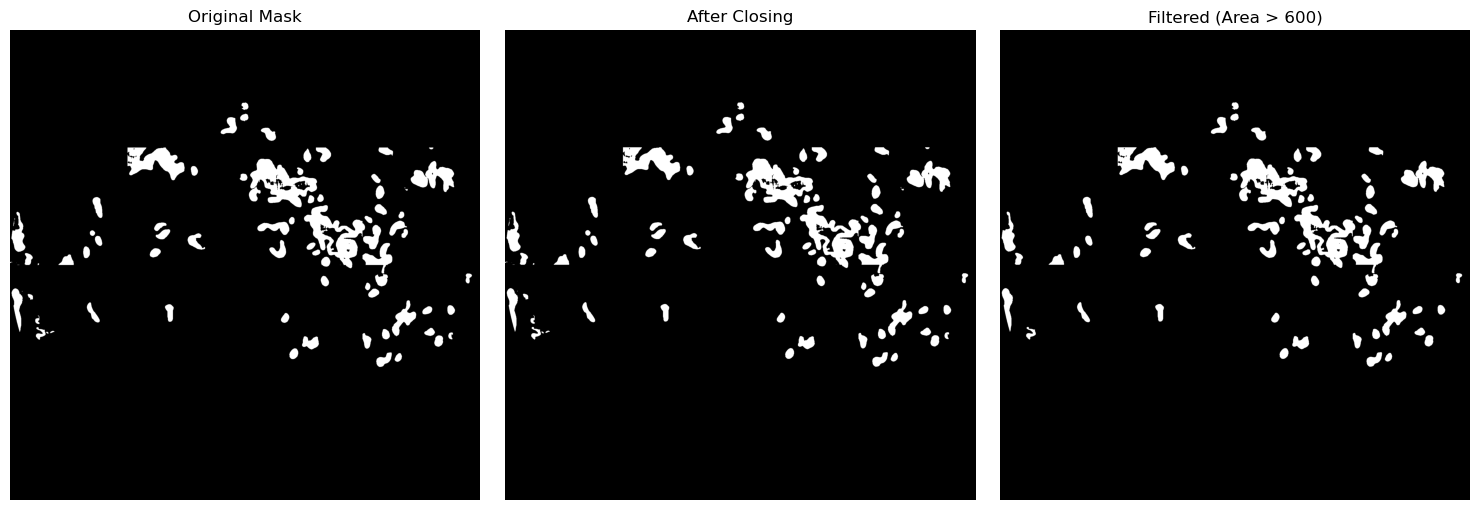

Processed file with timestamp: 1959-11-06T00:00:00


In [57]:
# Step 52: Import dependencies and initialise this stage.
import h5py
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datetime import datetime

def process_sunchart_mask(h5_file_path, area_threshold=600, kernel_size=(2,2), iterations=1): #80, 600
    """
    Process a sunchart mask from an HDF5 file with morphological operations and area filtering
    
    Args:
        h5_file_path (str): Path to the .h5 file
        area_threshold (int): Minimum area for connected components to keep
        kernel_size (tuple): Size of morphological kernel
        iterations (int): Number of iterations for morphological operations
        
    Returns:
        tuple: (original_mask, closed_mask, filtered_mask, timestamp)
    """
    with h5py.File(h5_file_path, "r") as f:
        # Read and preprocess mask
        mask = f["mask"][:].clip(max=1)
        mask = cv2.flip(mask, 1)  # Flip horizontally
        
        # Morphological closing
        kernel = np.ones(kernel_size, np.uint8)
        closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=iterations)
        
        # Connected component analysis
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(closing.astype(np.uint8), connectivity=8)#8
        
        # Filter by area
        filtered_mask = np.zeros_like(closing, dtype=np.uint8)
        for i in range(1, num_labels):  # Skip background (label 0)
            if stats[i, cv2.CC_STAT_AREA] >= area_threshold:
                filtered_mask[labels == i] = 1
                
        # Extract timestamp from filename
        filename = os.path.basename(h5_file_path)
        timestamp_str = os.path.splitext(filename)[0][:16]
        timestamp = datetime.strptime(timestamp_str, "sch_%Y%m%d_%H%M")
        
        return mask, closing, filtered_mask, timestamp

def plot_mask_results(original, processed, final, title_suffix=""):
    """Plot the three stages of mask processing"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    titles = ['Original Mask', 'After Closing', f'Filtered {title_suffix}']
    for ax, img, title in zip(axes, [original, processed, final], titles):
        ax.imshow(img, origin='lower', cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    h5_file_path = "/home/dibya/ML_work/sunchart_prediction_full_disk_1954_1/sch_19591106_0000_xxkt.h5"  # Replace with your file path
    area_threshold = 600  # Adjust as needed #600,80
    
    # Process the mask
    original_mask, closed_mask, filtered_mask, timestamp = process_sunchart_mask(
        h5_file_path, 
        area_threshold=area_threshold
    )
    
    # Plot results
    plot_title = f"(Area > {area_threshold})"
    plot_mask_results(original_mask, closed_mask, filtered_mask, plot_title)
    
    print(f"Processed file with timestamp: {timestamp.isoformat()}")

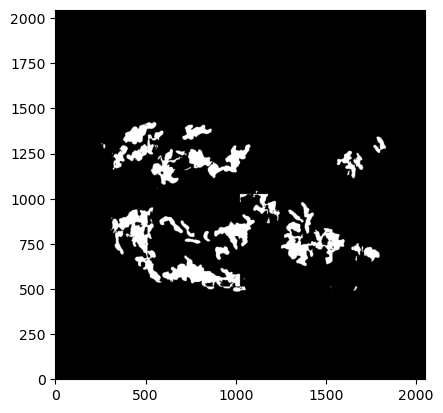

In [20]:
# Step 60: Visualise intermediate or final results.
plt.imshow(reconstruct[5],origin='lower',cmap='gray')